In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Python\Pandas\historical_automobile_sales.csv")

In [3]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [4]:
df.isnull().sum()

Date                       0
Year                       0
Month                      0
Recession                  0
Consumer_Confidence        0
Seasonality_Weight         0
Price                      0
Advertising_Expenditure    0
Competition                0
GDP                        0
Growth_Rate                0
unemployment_rate          0
Automobile_Sales           0
Vehicle_Type               0
City                       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    str    
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    str    
 3   Recession                528 non-null    int64  
 4   Consumer_Confidence      528 non-null    float64
 5   Seasonality_Weight       528 non-null    float64
 6   Price                    528 non-null    float64
 7   Advertising_Expenditure  528 non-null    int64  
 8   Competition              528 non-null    int64  
 9   GDP                      528 non-null    float64
 10  Growth_Rate              528 non-null    float64
 11  unemployment_rate        528 non-null    float64
 12  Automobile_Sales         528 non-null    float64
 13  Vehicle_Type             528 non-null    str    
 14  City                     528 non-null

In [7]:
df.drop(columns="Date", inplace=True)

In [8]:
df.drop(columns=["Consumer_Confidence", "Seasonality_Weight"], inplace=True)

<Axes: ylabel='Automobile_Sales'>

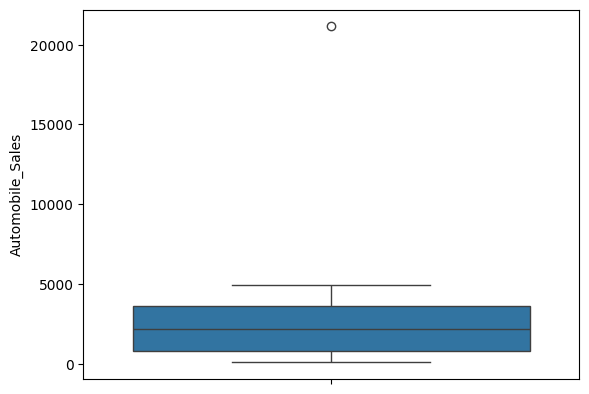

In [9]:
sns.boxplot(data=df, y="Automobile_Sales")

In [10]:
#Outlier columns: Recession,  Growth_Rate, unemployment_rate, Automobile_Sales
df["Growth_Rate"].describe()

count    528.000000
mean      -0.242001
std        0.861268
min       -4.227601
25%       -0.574049
50%       -0.013162
75%        0.388932
max        0.815074
Name: Growth_Rate, dtype: float64

In [11]:
q1 = -0.57
q3 = 0.38

In [12]:
IQR = q3 - q1 
IQR 

0.95

In [13]:
uf = q3 + 1.5*IQR 

In [14]:
lf = q1 - 1.5*IQR 

In [15]:
df = df[(df["Growth_Rate"]>lf)&(df["Growth_Rate"]<uf)]

<Axes: ylabel='Growth_Rate'>

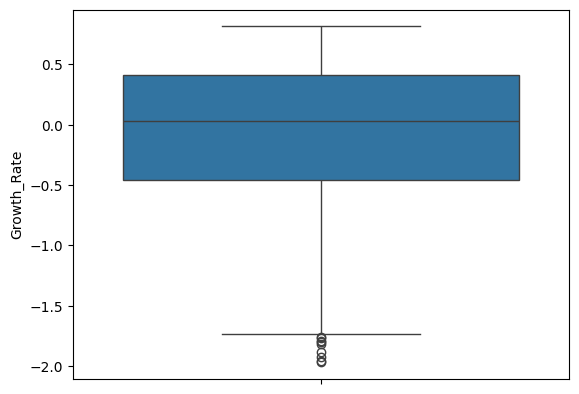

In [16]:
sns.boxplot(data=df, y="Growth_Rate")

In [17]:
df["unemployment_rate"].describe()

count    500.000000
mean       2.455000
std        1.107614
min        1.000000
25%        1.600000
50%        2.300000
75%        2.900000
max        5.900000
Name: unemployment_rate, dtype: float64

In [18]:
q1 = 1.6
q3 = 2.9

In [19]:
IQR = q3 - q1 
IQR 

1.2999999999999998

In [20]:
ub = q3 + 1.5*IQR 
lb = q1 - 1.5*IQR 

In [21]:
df = df[(df["unemployment_rate"]>lb)&(df["unemployment_rate"]<ub)]

<Axes: ylabel='unemployment_rate'>

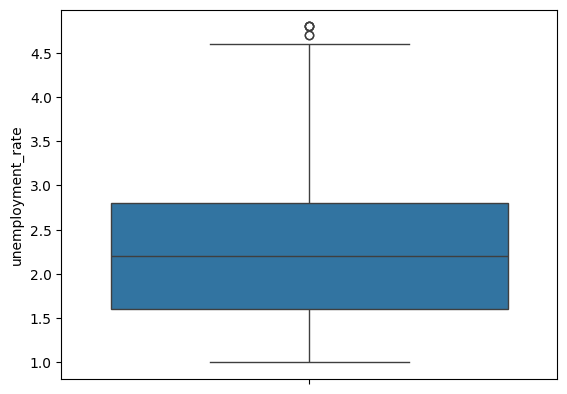

In [22]:
sns.boxplot(data=df, y="unemployment_rate")

In [23]:
df["Automobile_Sales"].describe()

count      470.000000
mean      2447.515404
std       1645.432136
min        214.000000
25%        947.450000
50%       2348.450000
75%       3640.425000
max      21147.000000
Name: Automobile_Sales, dtype: float64

In [24]:
q1 = 947.4
q3 = 3640.4

In [25]:
IQR = q3 - q1 

In [26]:
ub = q3 + 1.5*IQR
lb = q1 - 1.5*IQR

In [27]:
df = df[(df["Automobile_Sales"]>lb)&(df["Automobile_Sales"]<ub)]

<Axes: ylabel='Automobile_Sales'>

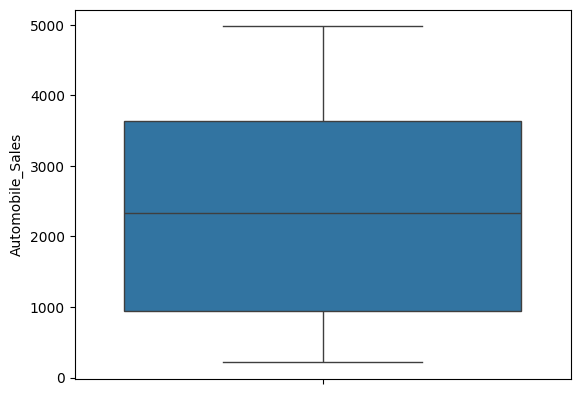

In [28]:
sns.boxplot(data=df, y="Automobile_Sales")

In [29]:
df.columns

Index(['Year', 'Month', 'Recession', 'Price', 'Advertising_Expenditure',
       'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate',
       'Automobile_Sales', 'Vehicle_Type', 'City'],
      dtype='str')

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
enc = LabelEncoder()

In [41]:
df["Month"] = enc.fit_transform(df["Month"])

In [42]:
df["Vehicle_Type"] = enc.fit_transform(df["Vehicle_Type"])

In [43]:
df["City"] = enc.fit_transform(df["City"])

In [44]:
x = df.drop("Price", axis=1)
y = df["Price"]

In [45]:
model = LinearRegression()

In [46]:
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_predict = model.predict(x)

In [48]:
from sklearn.metrics import r2_score 
r2_score(y, y_predict)

0.020266699085241147

ValueError: x and y must be the same size

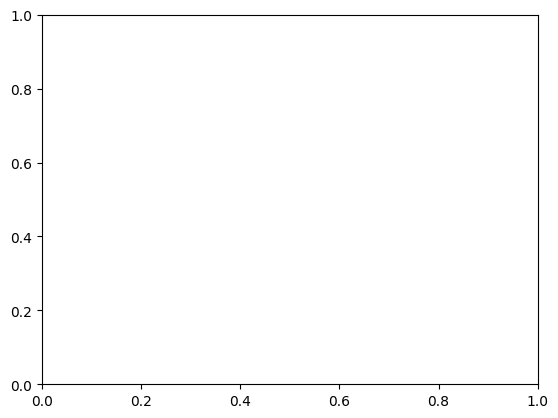

In [49]:
plt.scatter(x, y, label="Actual Values")
plt.plot(x, y_predict, label="Predicted Values")
plt.show()